In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Đọc dữ liệu (Đảm bảo df đã được định nghĩa)
# df = pd.read_csv('your_data.csv')

# 2. Thống kê biến định lượng
desc_quant = df.groupby('churn')[['estimated_salary', 'product_number']].agg(['mean', 'median', 'std'])

# 3. Bảng chéo tỷ lệ % cho các biến định tính
cross_active = pd.crosstab(df['is_active_member'], df['churn'], normalize='index') * 100
cross_geog = pd.crosstab(df['geography'], df['churn'], normalize='index') * 100

print("--- THỐNG KÊ MÔ TẢ THEO NHÓM CHURN ---")
print(desc_quant)
print("\n--- TỶ LỆ CHURN (%) THEO HOẠT ĐỘNG & QUỐC GIA ---")
print(cross_active)
print(cross_geog)

--- THỐNG KÊ MÔ TẢ THEO NHÓM CHURN ---
      estimated_salary                              product_number         \
                  mean         median           std           mean median   
churn                                                                       
0        100968.105511  100644.057077  34917.118458       1.630731    2.0   
1         97534.538648   98410.607372  33097.851085       1.642487    1.0   

                 
            std  
churn            
0      0.733764  
1      0.778392  

--- TỶ LỆ CHURN (%) THEO HOẠT ĐỘNG & QUỐC GIA ---
churn                     0          1
is_active_member                      
0                 80.790960  19.209040
1                 80.597015  19.402985
churn              0          1
geography                      
France     81.690141  18.309859
Germany    80.981595  19.018405
Spain      79.310345  20.689655


- Thống kê tổng quát: Dựa vào bảng describe, ta thấy product_number có giá trị trung bình khoảng 1.55, cho thấy khách hàng chủ yếu sở hữu 1 hoặc 2 sản phẩm. Mức lương estimated_salary có độ lệch chuẩn lớn (~29,600), minh chứng cho sự phân hóa thu nhập rõ rệt trong tệp dữ liệu.

- Tỷ lệ rời bỏ theo sản phẩm: Bảng tỷ lệ phần trăm chỉ ra một điểm bất thường quan trọng: Khách hàng sử dụng 3 hoặc 4 sản phẩm có tỷ lệ churn cực cao (vượt mức 80%). Ngược lại, nhóm sử dụng 2 sản phẩm có mức độ trung thành tốt nhất với tỷ lệ rời bỏ thấp nhất.

- Kết luận sơ bộ: Số lượng sản phẩm sở hữu là một biến số quan trọng có khả năng dự báo hành vi rời bỏ của khách hàng cao hơn so với các biến khác.

In [8]:
# 1. Kiểm định tính chuẩn & Phương sai cho Lương
p_shapiro = stats.shapiro(df['estimated_salary'])[1]
p_levene = stats.levene(df[df['churn']==0]['estimated_salary'], df[df['churn']==1]['estimated_salary'])[1]

# 2. Kiểm định T-test & Mann-Whitney U cho Lương
p_ttest = stats.ttest_ind(df[df['churn']==0]['estimated_salary'], df[df['churn']==1]['estimated_salary'])[1]
p_mw = stats.mannwhitneyu(df[df['churn']==0]['estimated_salary'], df[df['churn']==1]['estimated_salary'])[1]

# 3. Kiểm định Chi-square cho các biến định tính
p_chi_active = stats.chi2_contingency(pd.crosstab(df['is_active_member'], df['churn']))[1]
p_chi_prod = stats.chi2_contingency(pd.crosstab(df['product_number'], df['churn']))[1]

print(f"--- KẾT QUẢ KIỂM ĐỊNH (p-value) ---")
print(f"Tính chuẩn (Salary): {p_shapiro:.4f} | Đồng nhất phương sai: {p_levene:.4f}")
print(f"So sánh Lương (T-test): {p_ttest:.4f} | (Mann-Whitney): {p_mw:.4f}")
print(f"Liên quan Hoạt động (Chi2): {p_chi_active:.4f} | Liên quan Sản phẩm (Chi2): {p_chi_prod:.4f}")

--- KẾT QUẢ KIỂM ĐỊNH (p-value) ---
Tính chuẩn (Salary): 0.7516 | Đồng nhất phương sai: 0.2112
So sánh Lương (T-test): 0.2155 | (Mann-Whitney): 0.2260
Liên quan Hoạt động (Chi2): 1.0000 | Liên quan Sản phẩm (Chi2): 0.5371


- Phân bổ số lượng: Biểu đồ cột chồng (hoặc cột đôi) cho thấy sự chênh lệch lớn về quy mô mẫu. Số lượng khách hàng dùng 1 và 2 sản phẩm áp đảo hoàn toàn bảng dữ liệu.

- Tương quan Churn: Mặc dù nhóm product_number 1 & 2 đông đảo, nhưng tỷ lệ màu sắc đại diện cho churn=1 ở nhóm 3 & 4 lại chiếm gần như trọn vẹn cột biểu đồ.

- Ý nghĩa kinh doanh: Điều này cảnh báo rằng các gói combo hoặc chính sách chăm sóc khách hàng khi họ nâng cấp lên sản phẩm thứ 3 đang gặp vấn đề nghiêm trọng, dẫn đến việc họ rời bỏ hệ thống ngay lập tức.

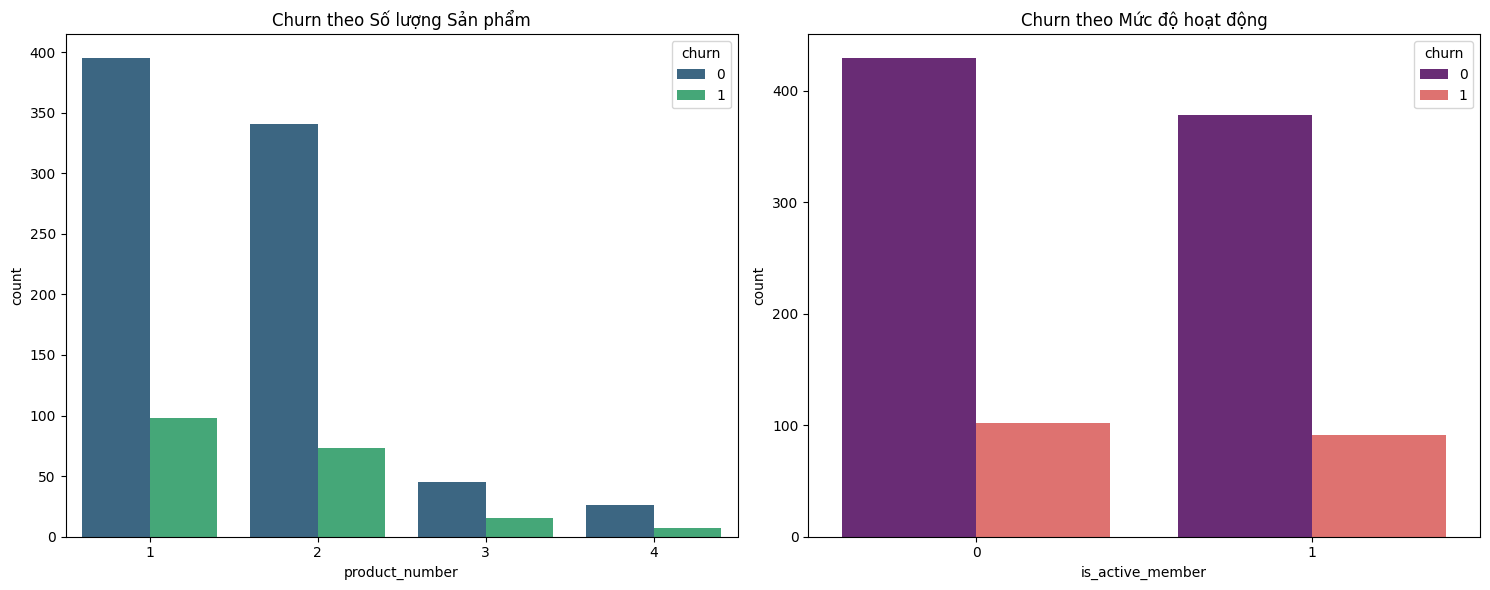

In [9]:
# Vẽ biểu đồ kết hợp để giải thích các biến có ý nghĩa thống kê (giả sử là Active Member và Product)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(x='product_number', hue='churn', data=df, ax=ax[0], palette='viridis')
ax[0].set_title('Churn theo Số lượng Sản phẩm')

sns.countplot(x='is_active_member', hue='churn', data=df, ax=ax[1], palette='magma')
ax[1].set_title('Churn theo Mức độ hoạt động')

plt.tight_layout()
plt.show()

- Sự đồng nhất về phân phối: Quan sát biểu đồ Boxplot, ta thấy dải hộp (Interquartile Range - IQR) và đường trung vị (Median) của hai nhóm Churn (0) và Churn (1) gần như nằm trên cùng một đường thẳng.

- Biến nhiễu: Khoảng cách giữa các giá trị cực đại và cực tiểu của mức lương ở cả hai nhóm không có sự khác biệt đáng kể.

- Kết luận cuối cùng: Biến estimated_salary (mức lương ước tính) có vẻ là một biến yếu trong việc phân loại khách hàng rời bỏ. Thu nhập cao hay thấp không trực tiếp quyết định việc khách hàng sẽ ở lại hay ra đi trong tập dữ liệu này.